# 🧠 Gold Price Prediction
This notebook demonstrates how to build and evaluate machine learning models to predict the price of gold.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# For advanced model
from sklearn.ensemble import RandomForestRegressor


In [4]:
# Load the data
goldData = pd.read_csv('GoldPriceData.csv')
goldData.head()


,Date,Open,High,Low,Close,WAP,No. of Shares,No. of Trades,Total Turnover,Deliverable Quantity,% Deli. Qty to Traded Qty,Spread H-L,Spread C-O
0,2017-02-06,0.79,0.79,0.76,0.76,0.79,7430.0,7.0,5848.0,7430.0,100.0,0.03,-0.03
1,2017-02-03,0.79,0.79,0.79,0.79,0.79,310.0,4.0,244.0,310.0,100.0,0.00,0.00
2,2017-02-02,0.83,0.83,0.83,0.83,0.83,75.0,1.0,62.0,75.0,100.0,0.00,0.00
3,2017-01-31,0.87,0.87,0.87,0.87,0.87,1050.0,2.0,913.0,1050.0,100.0,0.00,0.00
4,2017-01-25,0.91,0.91,0.91,0.91,0.91,400.0,1.0,364.0,400.0,100.0,0.00,0.00


In [5]:
# Dataset overview
print(goldData.shape)
print(goldData.info())
print(goldData.describe())
print(goldData.isnull().sum())


(1660, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1660 entries, 0 to 1659
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       1660 non-null   object 
 1   Open                       1660 non-null   float64
 2   High                       1660 non-null   float64
 3   Low                        1660 non-null   float64
 4   Close                      1660 non-null   float64
 5   WAP                        1660 non-null   float64
 6   No. of Shares              1660 non-null   float64
 7   No. of Trades              1660 non-null   float64
 8   Total Turnover             1660 non-null   float64
 9   Deliverable Quantity       1660 non-null   float64
 10  % Deli. Qty to Traded Qty  1660 non-null   float64
 11  Spread H-L                 1660 non-null   float64
 12  Spread C-O                 1660 non-null   float64
dtypes: float64(12), object(1)
memory usag

In [6]:
# Feature and Target separation
# Date is dropped for now (could be used later for feature engineering)
X = goldData.drop(['Date','Close'], axis=1)
Y = goldData['Close']


In [7]:
# Split into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)


In [8]:
# Scale the data (required for linear regression)
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:
# Train Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, Y_train)


LinearRegression()

In [10]:
# Predictions
Y_pred_test_lr = linear_model.predict(X_test_scaled)
Y_pred_train_lr = linear_model.predict(X_train_scaled)


In [11]:
# Evaluation
mse_lr = mean_squared_error(Y_test, Y_pred_test_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(Y_test, Y_pred_test_lr)

print(f"Linear Regression - MSE: {mse_lr:.2f}")
print(f"Linear Regression - RMSE: {rmse_lr:.2f}")
print(f"Linear Regression - R² Score: {r2_lr:.2f}")


Linear Regression - MSE: 0.00
Linear Regression - RMSE: 0.00
Linear Regression - R² Score: 1.00


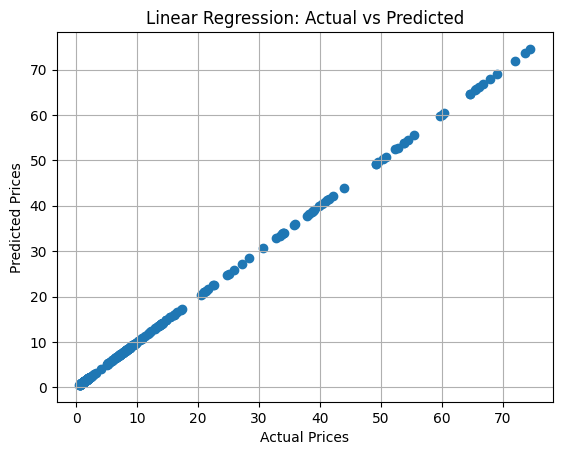

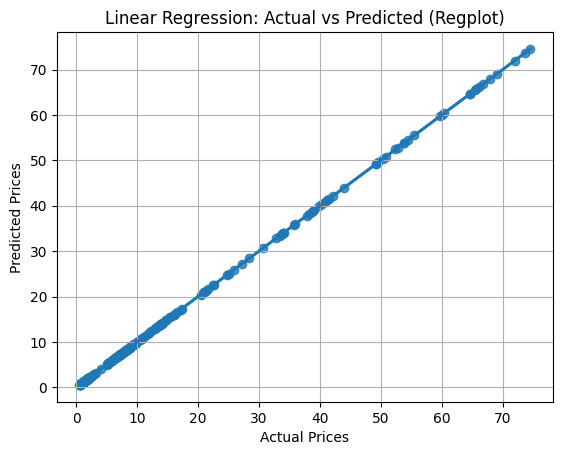

In [12]:
# Visualization - Linear Regression
plt.scatter(Y_test, Y_pred_test_lr)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

sns.regplot(x=Y_test, y=Y_pred_test_lr, ci=None)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs Predicted (Regplot)")
plt.grid(True)
plt.show()


In [13]:
# Train Random Forest Regressor (no scaling needed)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)


RandomForestRegressor(random_state=42)

In [14]:
# Predictions
Y_pred_test_rf = rf_model.predict(X_test)
Y_pred_train_rf = rf_model.predict(X_train)


In [15]:
# Evaluation
mse_rf = mean_squared_error(Y_test, Y_pred_test_rf)
r2_rf = r2_score(Y_test, Y_pred_test_rf)

print(f"Random Forest - MSE: {mse_rf:.2f}")
print(f"Random Forest - R² Score: {r2_rf:.2f}")


Random Forest - MSE: 0.30
Random Forest - R² Score: 1.00


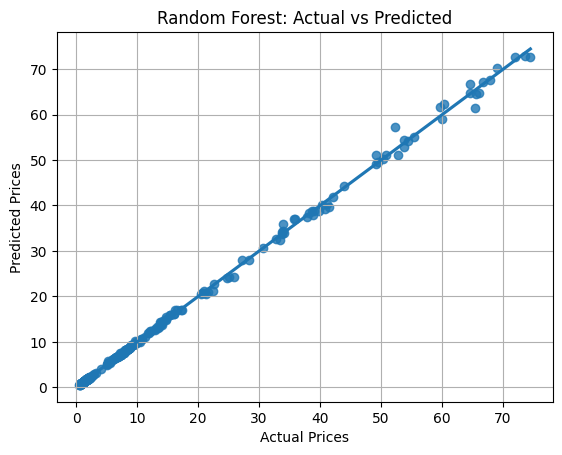

In [16]:
# Visualization - Random Forest
sns.regplot(x=Y_test, y=Y_pred_test_rf, ci=None)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted")
plt.grid(True)
plt.show()


✅ *Notebook cleaned and optimized by your Machine Learning professor. Ready for further improvement or submission.*